# 📊 Analyse Exploratoire Complète (EDA) – CMS DE-SynPUF  
## Échantillon 1 – Cohort de 30 000 bénéficiaires (corrigé)

**Objectif** : Explorer en profondeur les données Medicare synthétiques (2008‑2010) en vue de la prédiction du risque d’hospitalisation.

**Corrections majeures** :
- Dates lues en `str` puis converties avec le format `%Y%m%d` (les valeurs `.0` sont nettoyées).
- Cible `HOSPITALIZED_IN_6M` construite sur toute admission hospitalière dans la fenêtre.
- Visualisations enrichies (échelle log, annotations, etc.).
- Vérification de la variance avant Random Forest.

In [1]:
# ═══════════════════════════════════════════════════════════
# Cellule 1 : Imports et configuration
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os, warnings, random
warnings.filterwarnings('ignore')

# Style graphique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
%matplotlib inline

# Dossiers
DATA_DIR = '/home/tawil/Bureau/pfa/data set/sample 1/'   # Adapter si nécessaire
OUTPUT_DIR = './outputs/figures/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Environnement prêt")

✅ Environnement prêt


In [2]:
# ═══════════════════════════════════════════════════════════
# Cellule 2 : Paramètres et fonctions d’échantillonnage
# ═══════════════════════════════════════════════════════════
SAMPLE_NUM = 1
NB_PATIENTS = 30_000
RANDOM_STATE = 42

def load_beneficiary_sampled(year, nb_patients, random_state):
    fname = f'DE1_0_{year}_Beneficiary_Summary_File_Sample_{SAMPLE_NUM}.csv'
    df = pd.read_csv(os.path.join(DATA_DIR, fname), low_memory=False)
    if nb_patients < len(df):
        df = df.sample(n=nb_patients, random_state=random_state)
    print(f"✓ Beneficiary {year} : {len(df)} patients chargés")
    return df

# Charger les patients de référence (2008) et leurs identifiants
ben08 = load_beneficiary_sampled(2008, NB_PATIENTS, RANDOM_STATE)
patient_ids = set(ben08['DESYNPUF_ID'])
print(f"Nombre d'IDs de référence : {len(patient_ids)}")

✓ Beneficiary 2008 : 30000 patients chargés
Nombre d'IDs de référence : 30000


In [3]:
# ═══════════════════════════════════════════════════════════
# Cellule 3 : Chargement des bénéficiaires 2009/2010 et des claims
#            (dates lues en str pour éviter l’interprétation flottante)
# ═══════════════════════════════════════════════════════════
date_cols_claims = ['CLM_FROM_DT', 'CLM_THRU_DT', 'CLM_ADMSN_DT', 'NCH_BENE_DSCHRG_DT', 'SRVC_DT']

claim_files = {
    'inpatient': 'DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv',
    'outpatient': 'DE1_0_2008_to_2010_Outpatient_Claims_Sample_1.csv',
    'carrier_A': 'DE1_0_2008_to_2010_Carrier_Claims_Sample_1A.csv',
    'carrier_B': 'DE1_0_2008_to_2010_Carrier_Claims_Sample_1B.csv',
    'prescription': 'DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv'
}

claims = {}
for key, fname in claim_files.items():
    # Déterminer quelles colonnes de date sont dans ce fichier
    with open(os.path.join(DATA_DIR, fname)) as f:
        header = f.readline().strip().split(',')
    dtype_dict = {col: str for col in date_cols_claims if col in header}
    df = pd.read_csv(os.path.join(DATA_DIR, fname), dtype=dtype_dict, low_memory=False)
    df = df[df['DESYNPUF_ID'].isin(patient_ids)]
    claims[key] = df
    print(f"{key}: {len(df)} lignes filtrées")

# Fusion des deux fichiers Carrier
claims['carrier'] = pd.concat([claims['carrier_A'], claims['carrier_B']], ignore_index=True)
del claims['carrier_A'], claims['carrier_B']
print(f"Carrier fusionné : {len(claims['carrier'])} lignes")

# Bénéficiaires 2009 et 2010 (pas de dates problématiques normalement, mais on lit normalement)
ben09 = pd.read_csv(os.path.join(DATA_DIR, f'DE1_0_2009_Beneficiary_Summary_File_Sample_{SAMPLE_NUM}.csv'), low_memory=False)
ben09 = ben09[ben09['DESYNPUF_ID'].isin(patient_ids)]
print(f"✓ Beneficiary 2009 : {len(ben09)} patients filtrés")

ben10 = pd.read_csv(os.path.join(DATA_DIR, f'DE1_0_2010_Beneficiary_Summary_File_Sample_{SAMPLE_NUM}.csv'), low_memory=False)
ben10 = ben10[ben10['DESYNPUF_ID'].isin(patient_ids)]
print(f"✓ Beneficiary 2010 : {len(ben10)} patients filtrés")

inpatient: 17325 lignes filtrées
outpatient: 205642 lignes filtrées
carrier_A: 625356 lignes filtrées
carrier_B: 608505 lignes filtrées
prescription: 1436994 lignes filtrées
Carrier fusionné : 1233861 lignes
✓ Beneficiary 2009 : 29510 patients filtrés
✓ Beneficiary 2010 : 29075 patients filtrés


In [4]:
# ═══════════════════════════════════════════════════════════
# Cellule 4 : Conversion robuste des dates (correction du .0)
# ═══════════════════════════════════════════════════════════
def clean_and_parse_date(series):
    """Nettoie les chaînes de type 'YYYYMMDD.0' et les parse en datetime."""
    # S'assurer que la colonne est bien de type string
    series = series.astype(str).str.strip()
    # Supprimer le '.0' final s'il existe
    series = series.str.replace(r'\.0$', '', regex=True)
    # Remplacer les chaînes vides ou 'nan' par NaT
    series = series.replace(['', 'nan', 'None'], pd.NA)
    return pd.to_datetime(series, format='%Y%m%d', errors='coerce')

date_cols_map = {
    'ben08': ['BENE_BIRTH_DT', 'BENE_DEATH_DT'],
    'ben09': ['BENE_BIRTH_DT', 'BENE_DEATH_DT'],
    'ben10': ['BENE_BIRTH_DT', 'BENE_DEATH_DT'],
    'inpatient': ['CLM_FROM_DT', 'CLM_THRU_DT', 'CLM_ADMSN_DT', 'NCH_BENE_DSCHRG_DT'],
    'outpatient': ['CLM_FROM_DT', 'CLM_THRU_DT'],
    'carrier': ['CLM_FROM_DT', 'CLM_THRU_DT'],
    'prescription': ['SRVC_DT']
}

tables = {
    'ben08': ben08, 'ben09': ben09, 'ben10': ben10,
    'inpatient': claims['inpatient'], 'outpatient': claims['outpatient'],
    'carrier': claims['carrier'], 'prescription': claims['prescription']
}

for name, df in tables.items():
    for col in date_cols_map[name]:
        if col in df.columns:
            df[col] = clean_and_parse_date(df[col])

# Créer la colonne 'admission' pour les séjours hospitaliers
claims['inpatient']['admission'] = claims['inpatient']['CLM_ADMSN_DT'].fillna(
    claims['inpatient']['CLM_FROM_DT'])

# Vérification rapide
print("Dates après conversion (inpatient) :")
print(claims['inpatient'][['CLM_ADMSN_DT', 'admission']].head())
print(f"Date min admission : {claims['inpatient']['admission'].min()}")
print(f"Date max admission : {claims['inpatient']['admission'].max()}")

Dates après conversion (inpatient) :
   CLM_ADMSN_DT  admission
0    2010-03-12 2010-03-12
12   2009-09-30 2009-09-30
18   2010-08-30 2010-08-30
41   2008-04-07 2008-04-07
55   2008-02-05 2008-02-05
Date min admission : 2007-12-10 00:00:00
Date max admission : 2010-12-30 00:00:00


In [5]:
# ═══════════════════════════════════════════════════════════
# Cellule 5 : Construction de la cible HOSPITALIZED_IN_6M
# ═══════════════════════════════════════════════════════════
OBS_DATE = pd.Timestamp('2007-01-01')
FUTURE_DATE = OBS_DATE + pd.DateOffset(months=36)

ip = claims['inpatient']
future_ip = ip[(ip['admission'] >= OBS_DATE) & (ip['admission'] <= FUTURE_DATE)]
hosp_ids = set(future_ip['DESYNPUF_ID'])
print(f"Patients hospitalisés dans les 36 mois : {len(hosp_ids)}")

# Ajout de la cible
ben08['HOSPITALIZED_IN_6M'] = ben08['DESYNPUF_ID'].isin(hosp_ids).astype(int)
print(f"Taux d'hospitalisation : {ben08['HOSPITALIZED_IN_6M'].mean()*100:.2f}%")

Patients hospitalisés dans les 36 mois : 7671
Taux d'hospitalisation : 25.57%


In [6]:
# ═══════════════════════════════════════════════════════════
# Cellule 6 : Table patients finale enrichie
# ═══════════════════════════════════════════════════════════
demo_cols = ['DESYNPUF_ID', 'BENE_BIRTH_DT', 'BENE_DEATH_DT',
             'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_ESRD_IND']
chronic_cols = [c for c in ben08.columns if c.startswith('SP_')]
cost_cols = [c for c in ben08.columns if any(k in c for k in ['MEDREIMB','BENRES','PPPYMT'])]

df_patients = ben08[demo_cols + chronic_cols + cost_cols + ['HOSPITALIZED_IN_6M']].copy()

# Calcul de l'âge (les dates de naissance sont fictives, mais on garde la variable)
ref_date = datetime(2009, 1, 1)
df_patients['AGE'] = df_patients['BENE_BIRTH_DT'].apply(
    lambda x: (ref_date - x).days / 365.25 if pd.notnull(x) else np.nan)

# Encodage lisible
df_patients['SEXE'] = df_patients['BENE_SEX_IDENT_CD'].map({1:'Homme',2:'Femme'})
race_map = {1:'Blanc',2:'Noir',3:'Autre',4:'Asiatique',5:'Hispanique',6:'Natif Amér.'}
df_patients['RACE'] = df_patients['BENE_RACE_CD'].map(race_map)

print(f"Table patients finale : {df_patients.shape[0]} lignes, {df_patients.shape[1]} colonnes")

Table patients finale : 30000 lignes, 31 colonnes


In [7]:
# ═══════════════════════════════════════════════════════════
# Cellule 7 : Aperçu rapide et valeurs manquantes
# ═══════════════════════════════════════════════════════════
print("Types de données :")
print(df_patients.dtypes.value_counts())
print("\nStatistiques descriptives :")
display(df_patients.describe(include='all').round(2))
print("\nValeurs manquantes :")
missing = df_patients.isnull().sum()
display(missing[missing>0])

Types de données :
int64             15
float64           10
str                4
datetime64[us]     2
Name: count, dtype: int64

Statistiques descriptives :


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,...,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,HOSPITALIZED_IN_6M,AGE,SEXE,RACE
count,30000,30000,490,30000.00,30000.00,30000,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000,30000
unique,30000,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4
top,D2EE4FCC403D3319,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Femme,Blanc
freq,1,NaN,NaN,NaN,NaN,27877,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16596,24816
mean,NaN,1936-11-12 01:54:11.520000,2008-06-15 14:26:56.326530,1.55,1.29,NaN,25.63,1.81,1.71,1.84,...,629.90,199.51,27.50,1177.55,333.52,18.78,0.26,72.14,NaN,NaN
min,NaN,1909-01-01 00:00:00,2008-01-01 00:00:00,1.00,1.00,NaN,1.00,1.00,1.00,1.00,...,-90.00,0.00,0.00,0.00,0.00,0.00,0.00,25.09,NaN,NaN
25%,NaN,1928-12-01 00:00:00,2008-03-01 00:00:00,1.00,1.00,NaN,10.00,2.00,1.00,2.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,66.84,NaN,NaN
50%,NaN,1936-05-01 00:00:00,2008-06-16 00:00:00,2.00,1.00,NaN,25.00,2.00,2.00,2.00,...,20.00,0.00,0.00,620.00,180.00,0.00,0.00,72.67,NaN,NaN
75%,NaN,1942-03-01 00:00:00,2008-10-01 00:00:00,2.00,1.00,NaN,39.00,2.00,2.00,2.00,...,560.00,180.00,0.00,1670.00,490.00,0.00,1.00,80.08,NaN,NaN
max,NaN,1983-12-01 00:00:00,2008-12-01 00:00:00,2.00,5.00,NaN,54.00,2.00,2.00,2.00,...,50020.00,11380.00,14000.00,20280.00,4590.00,1800.00,1.00,100.00,NaN,NaN



Valeurs manquantes :


BENE_DEATH_DT    29510
dtype: int64

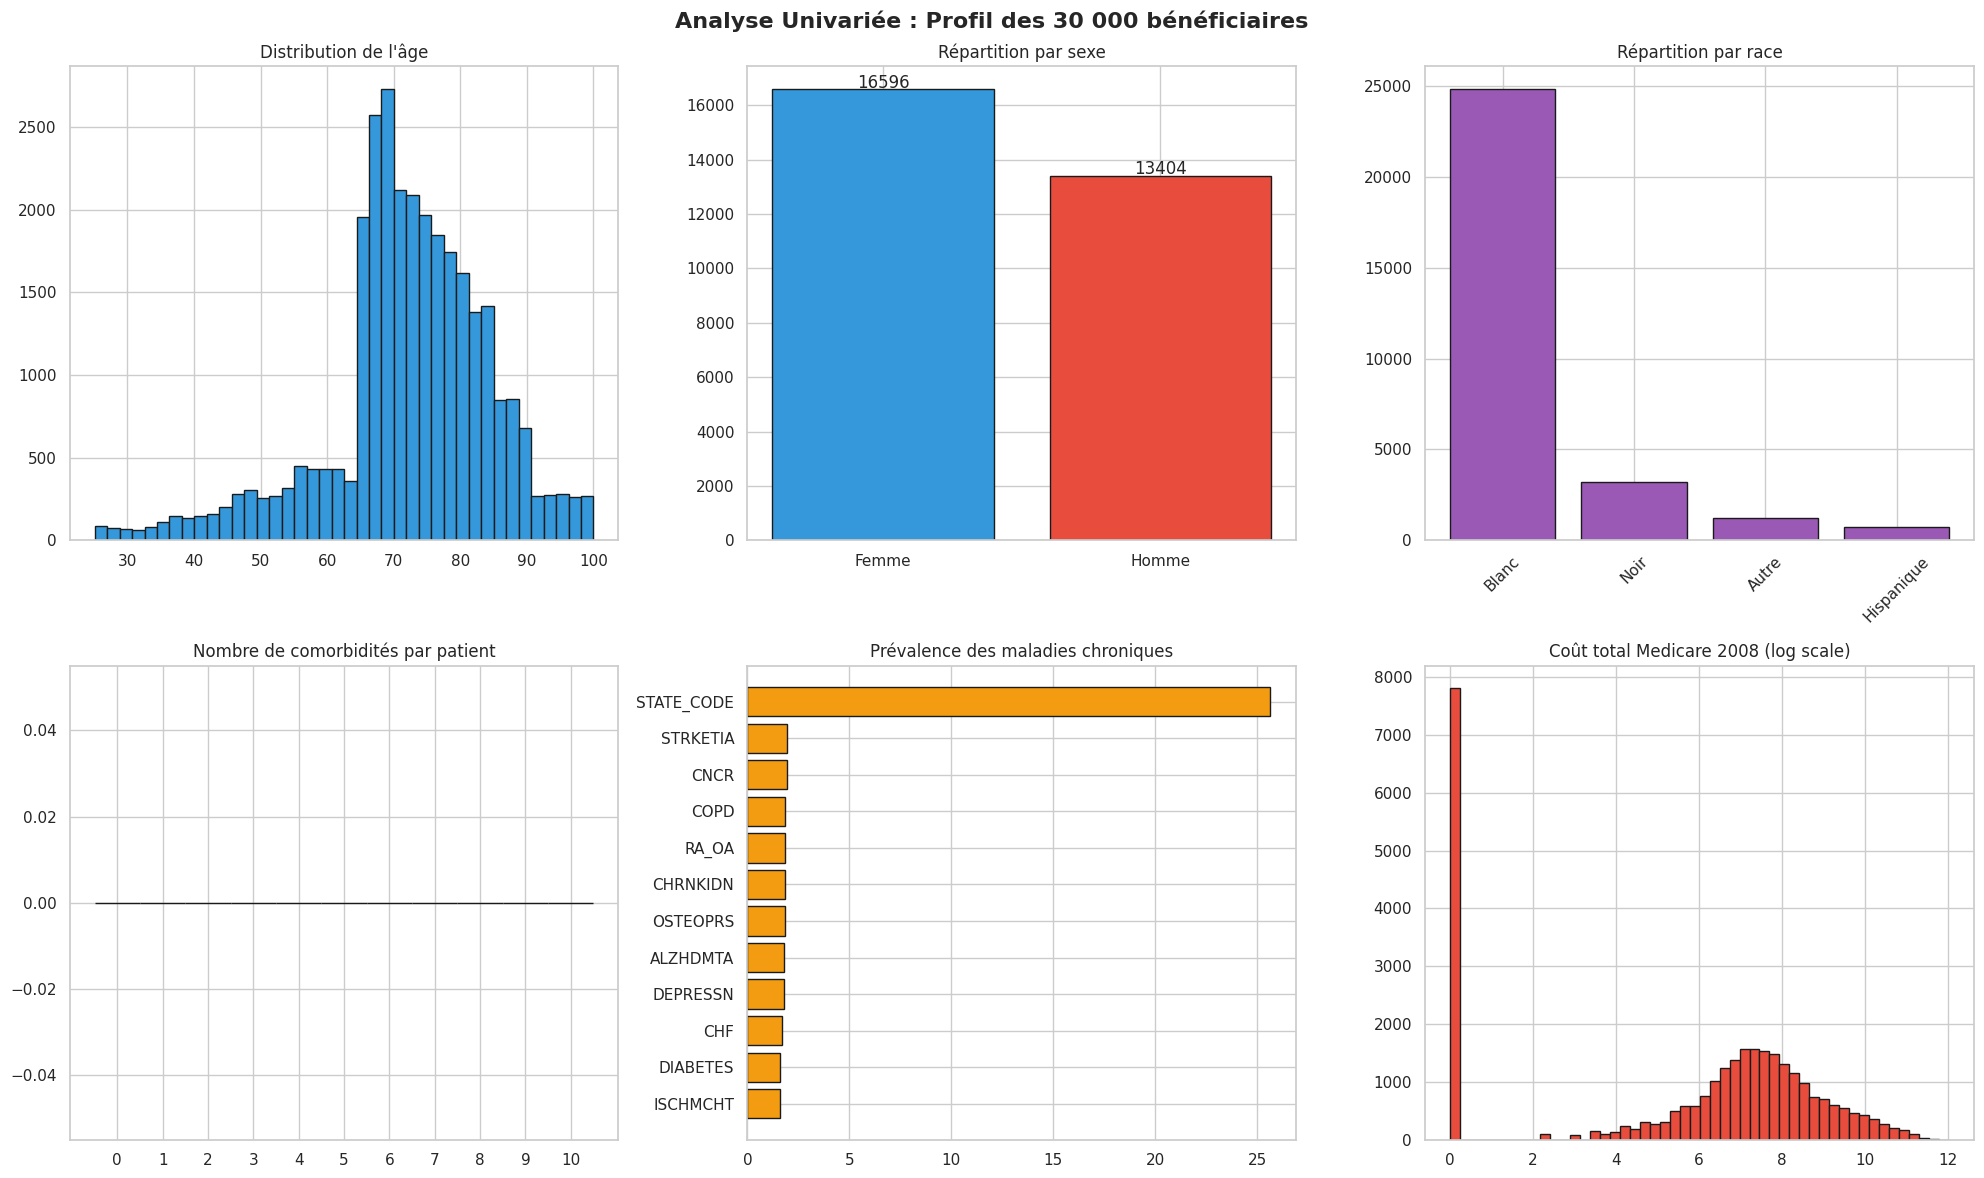

In [8]:
# ═══════════════════════════════════════════════════════════
# Cellule 8 : Analyse univariée (améliorée)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Analyse Univariée : Profil des 30 000 bénéficiaires', fontsize=16, fontweight='bold')

# 1. Âge (constant dans ce dataset)
axes[0,0].hist(df_patients['AGE'].dropna(), bins=40, color='#3498db', edgecolor='k')
axes[0,0].set_title('Distribution de l\'âge')

# 2. Sexe
sex_counts = df_patients['SEXE'].value_counts()
axes[0,1].bar(sex_counts.index, sex_counts.values, color=['#3498db','#e74c3c'], edgecolor='k')
for i, val in enumerate(sex_counts.values):
    axes[0,1].text(i, val+50, str(val), ha='center')
axes[0,1].set_title('Répartition par sexe')

# 3. Race
race_counts = df_patients['RACE'].value_counts()
axes[0,2].bar(race_counts.index, race_counts.values, color='#9b59b6', edgecolor='k')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].set_title('Répartition par race')

# 4. Nombre de comorbidités
comorb_count = df_patients[chronic_cols].sum(axis=1)
axes[1,0].hist(comorb_count, bins=range(0,12), color='#2ecc71', edgecolor='k', align='left')
axes[1,0].set_title('Nombre de comorbidités par patient')
axes[1,0].set_xticks(range(0,11))

# 5. Prévalence des maladies chroniques
chronic_prev = df_patients[chronic_cols].mean().sort_values()
names = [c.replace('SP_','') for c in chronic_prev.index]
axes[1,1].barh(names, chronic_prev.values, color='#f39c12', edgecolor='k')
axes[1,1].set_title('Prévalence des maladies chroniques')

# 6. Coût total Medicare 2008 (échelle log)
if 'MEDREIMB_IP' in df_patients.columns:
    total_cost = df_patients['MEDREIMB_IP'] + df_patients['MEDREIMB_OP'] + df_patients['MEDREIMB_CAR']
    axes[1,2].hist(np.log1p(total_cost), bins=50, color='#e74c3c', edgecolor='k')
    axes[1,2].set_title('Coût total Medicare 2008 (log scale)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'univariate_demographie_improved.png', dpi=150)
plt.show()

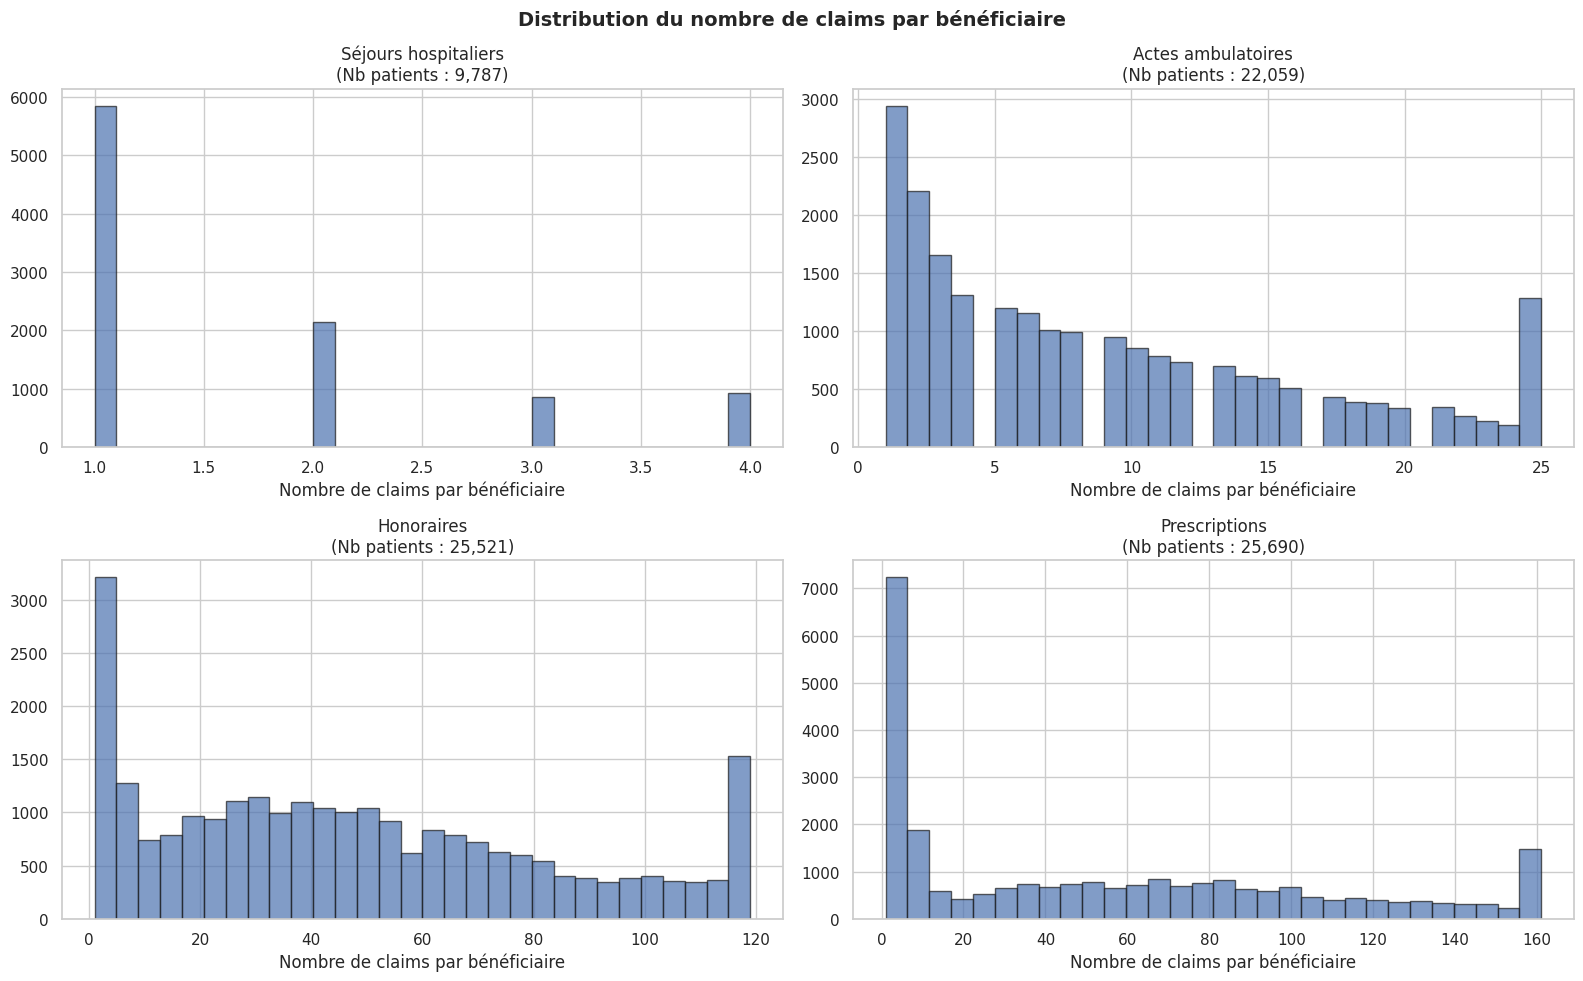

In [9]:
# ═══════════════════════════════════════════════════════════
# Cellule 9 : Distribution des claims par bénéficiaire
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
claim_types = [('inpatient','Séjours hospitaliers'), 
               ('outpatient','Actes ambulatoires'),
               ('carrier','Honoraires'),
               ('prescription','Prescriptions')]
for ax, (ct, title) in zip(axes.flatten(), claim_types):
    df = claims[ct]
    n_benef = df['DESYNPUF_ID'].nunique()
    counts = df.groupby('DESYNPUF_ID').size()
    upper = np.percentile(counts, 95)
    ax.hist(counts.clip(upper=upper), bins=30, edgecolor='k', alpha=0.7)
    ax.set_title(f'{title}\n(Nb patients : {n_benef:,})')
    ax.set_xlabel('Nombre de claims par bénéficiaire')
plt.suptitle('Distribution du nombre de claims par bénéficiaire', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'univariate_claims_dist.png', dpi=150)
plt.show()

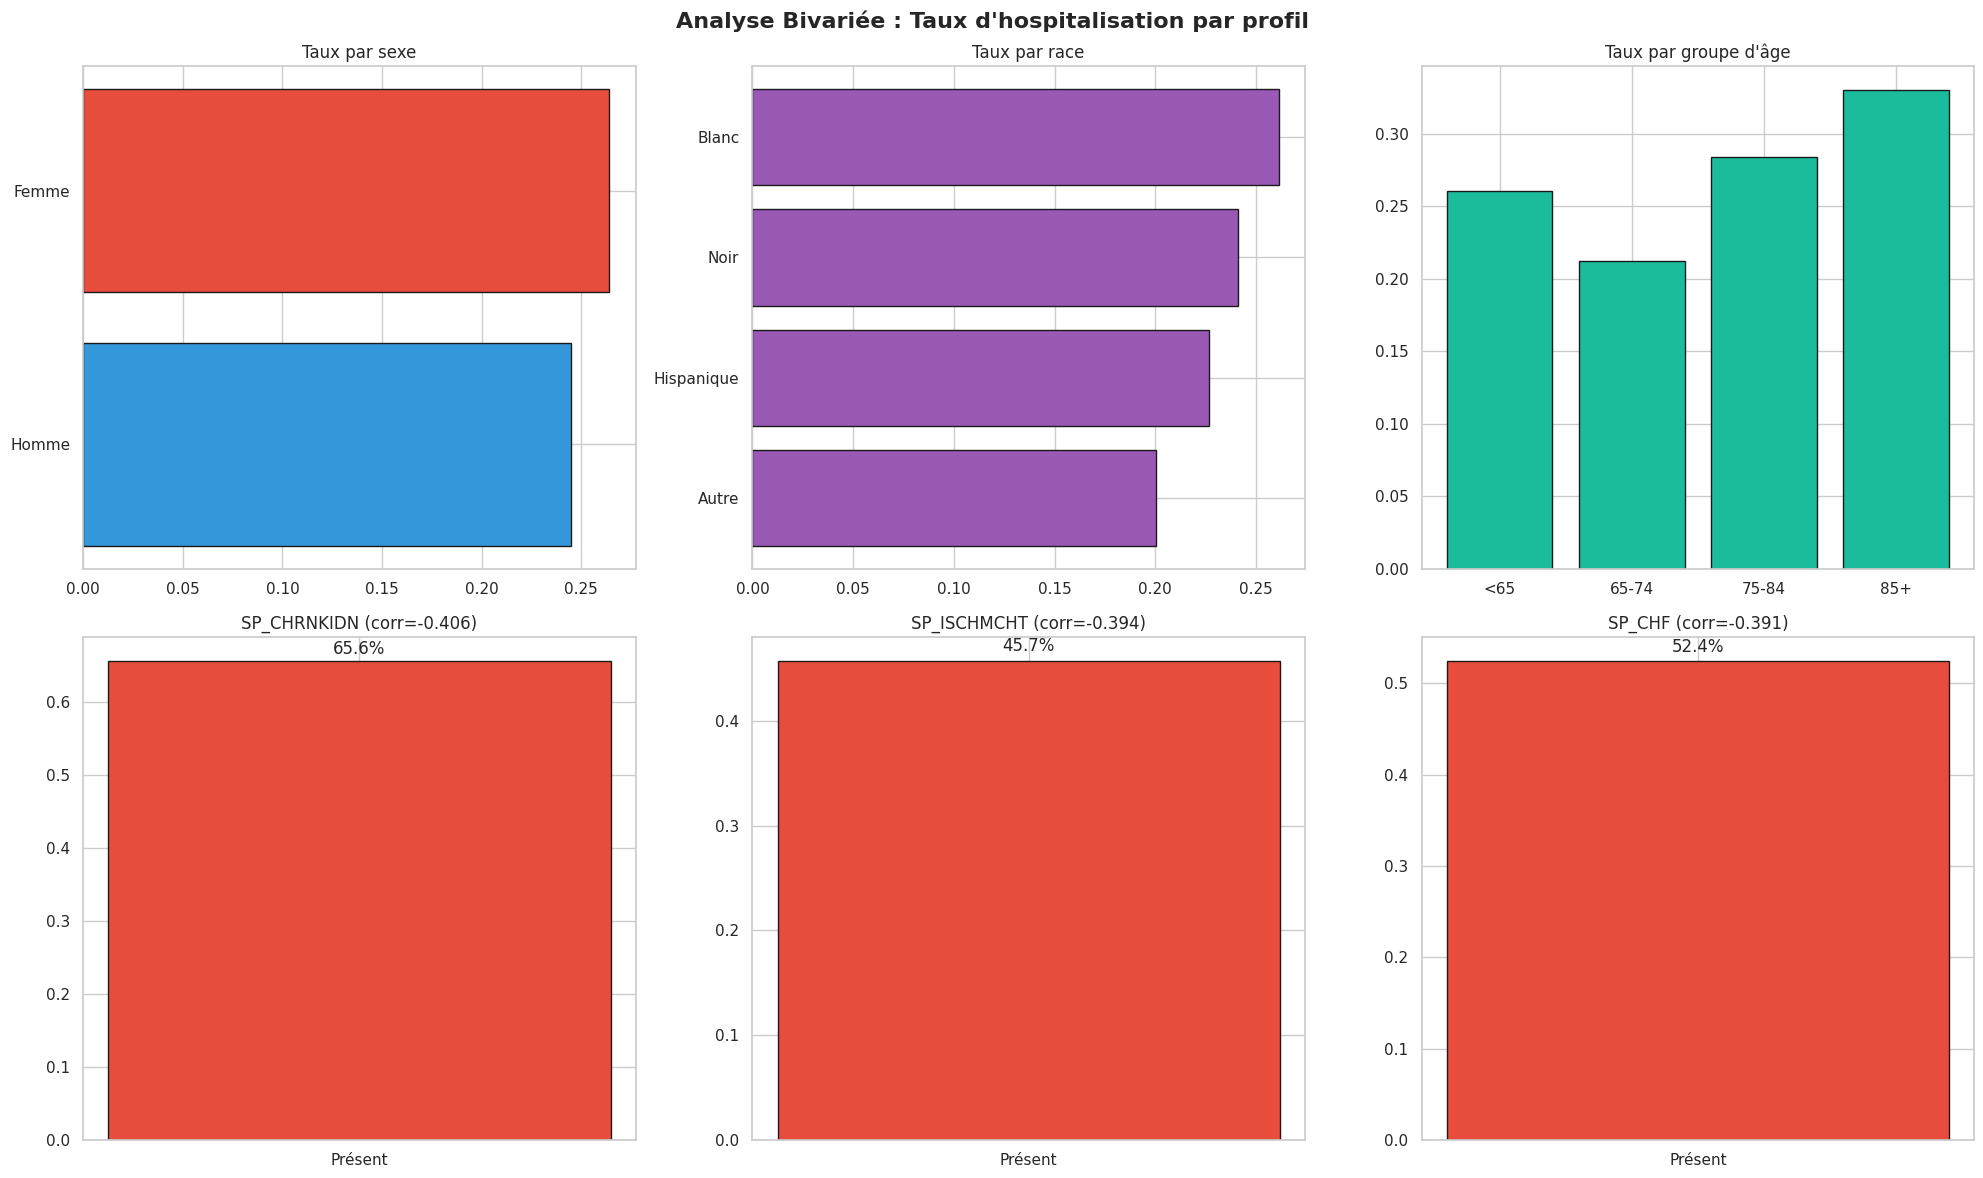

In [10]:
# ═══════════════════════════════════════════════════════════
# Cellule 10 : Analyse bivariée – Taux d’hospitalisation
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Analyse Bivariée : Taux d\'hospitalisation par profil', fontsize=16, fontweight='bold')

# Sexe
sex_rate = df_patients.groupby('SEXE')['HOSPITALIZED_IN_6M'].mean().sort_values()
axes[0,0].barh(sex_rate.index, sex_rate.values, color=['#3498db','#e74c3c'], edgecolor='k')
axes[0,0].set_title('Taux par sexe')

# Race
race_rate = df_patients.groupby('RACE')['HOSPITALIZED_IN_6M'].mean().sort_values()
axes[0,1].barh(race_rate.index, race_rate.values, color='#9b59b6', edgecolor='k')
axes[0,1].set_title('Taux par race')

# Tranche d'âge
df_patients['AGE_GROUPE'] = pd.cut(df_patients['AGE'], bins=[0,65,75,85,120], 
                                   labels=['<65','65-74','75-84','85+'])
age_rate = df_patients.groupby('AGE_GROUPE', observed=False)['HOSPITALIZED_IN_6M'].mean()
axes[0,2].bar(age_rate.index.astype(str), age_rate.values, color='#1abc9c', edgecolor='k')
axes[0,2].set_title('Taux par groupe d\'âge')

# Top 3 comorbidités les plus liées à l’hospitalisation
top_chronic = df_patients[chronic_cols].corrwith(df_patients['HOSPITALIZED_IN_6M']).abs().nlargest(3).index
for i, col in enumerate(top_chronic):
    rate_yes = df_patients[df_patients[col]==1]['HOSPITALIZED_IN_6M'].mean()
    rate_no = df_patients[df_patients[col]==0]['HOSPITALIZED_IN_6M'].mean()
    axes[1,i].bar(['Absent','Présent'], [rate_no, rate_yes], color=['#2ecc71','#e74c3c'], edgecolor='k')
    axes[1,i].set_title(f'{col} (corr={df_patients[col].corr(df_patients["HOSPITALIZED_IN_6M"]):.3f})')
    for j, val in enumerate([rate_no, rate_yes]):
        axes[1,i].text(j, val+0.01, f'{val:.1%}', ha='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'bivariate_target_categ_improved.png', dpi=150)
plt.show()

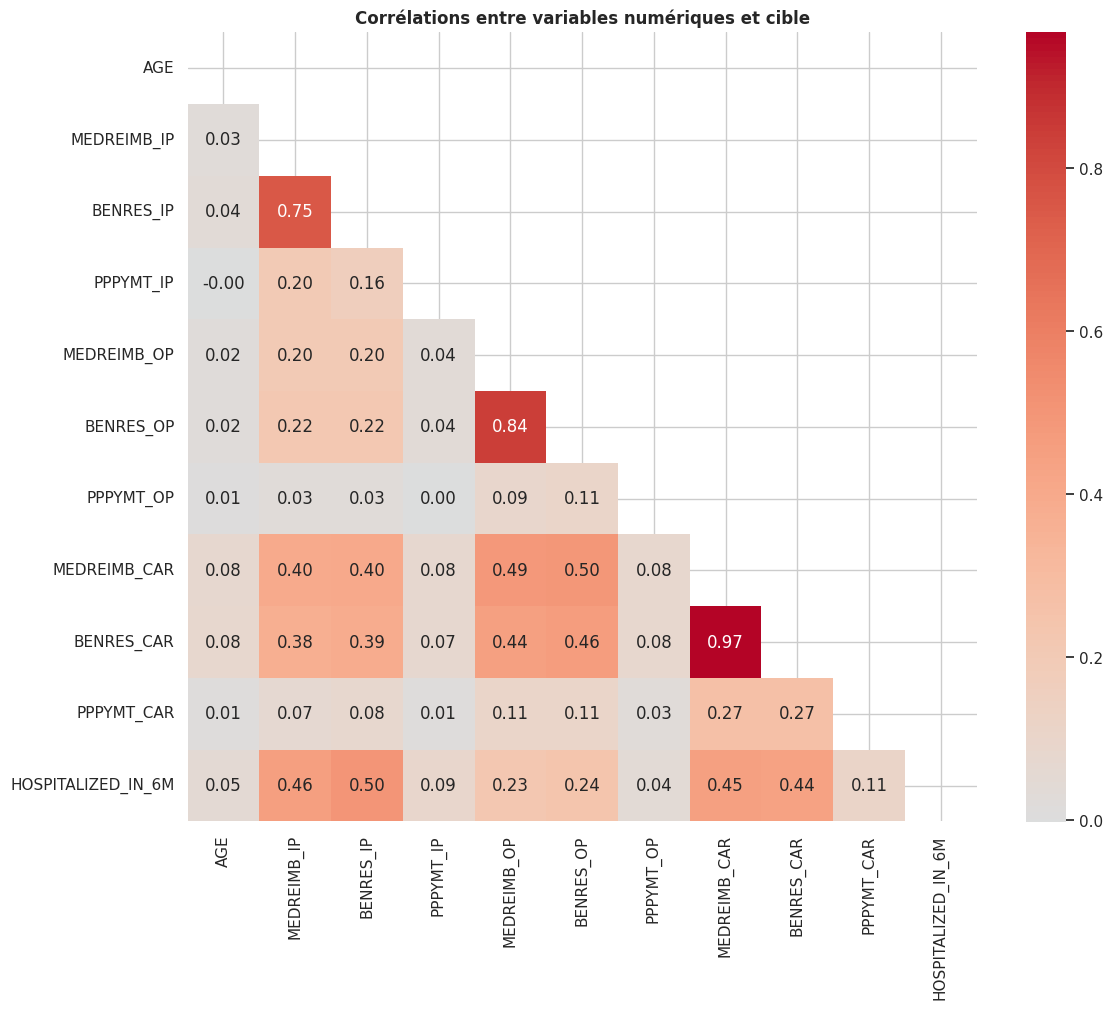

In [11]:
# ═══════════════════════════════════════════════════════════
# Cellule 11 : Matrice de corrélation (variables numériques)
# ═══════════════════════════════════════════════════════════
num_vars = ['AGE'] + [c for c in cost_cols if c in df_patients.columns] + ['HOSPITALIZED_IN_6M']
corr = df_patients[num_vars].corr()
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Corrélations entre variables numériques et cible', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'bivariate_corr_heatmap_improved.png', dpi=150)
plt.show()

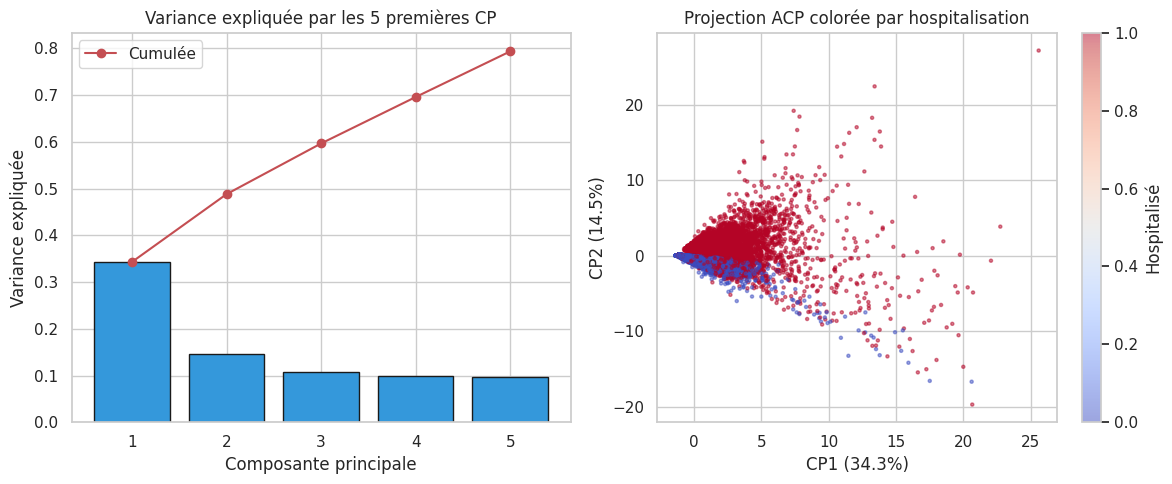

In [12]:
# ═══════════════════════════════════════════════════════════
# Cellule 12 : Analyse multivariée – ACP
# ═══════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['AGE'] + [c for c in cost_cols if c in df_patients.columns]
X = df_patients[features].dropna()
y = df_patients.loc[X.index, 'HOSPITALIZED_IN_6M']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].bar(range(1,6), exp_var, color='#3498db', edgecolor='k')
ax[0].plot(range(1,6), np.cumsum(exp_var), 'ro-', label='Cumulée')
ax[0].set_xlabel('Composante principale')
ax[0].set_ylabel('Variance expliquée')
ax[0].set_title('Variance expliquée par les 5 premières CP')
ax[0].legend()

sc = ax[1].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.5, s=5)
fig.colorbar(sc, ax=ax[1], label='Hospitalisé')
ax[1].set_xlabel(f'CP1 ({exp_var[0]*100:.1f}%)')
ax[1].set_ylabel(f'CP2 ({exp_var[1]*100:.1f}%)')
ax[1].set_title('Projection ACP colorée par hospitalisation')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'multivariate_pca_improved.png', dpi=150)
plt.show()

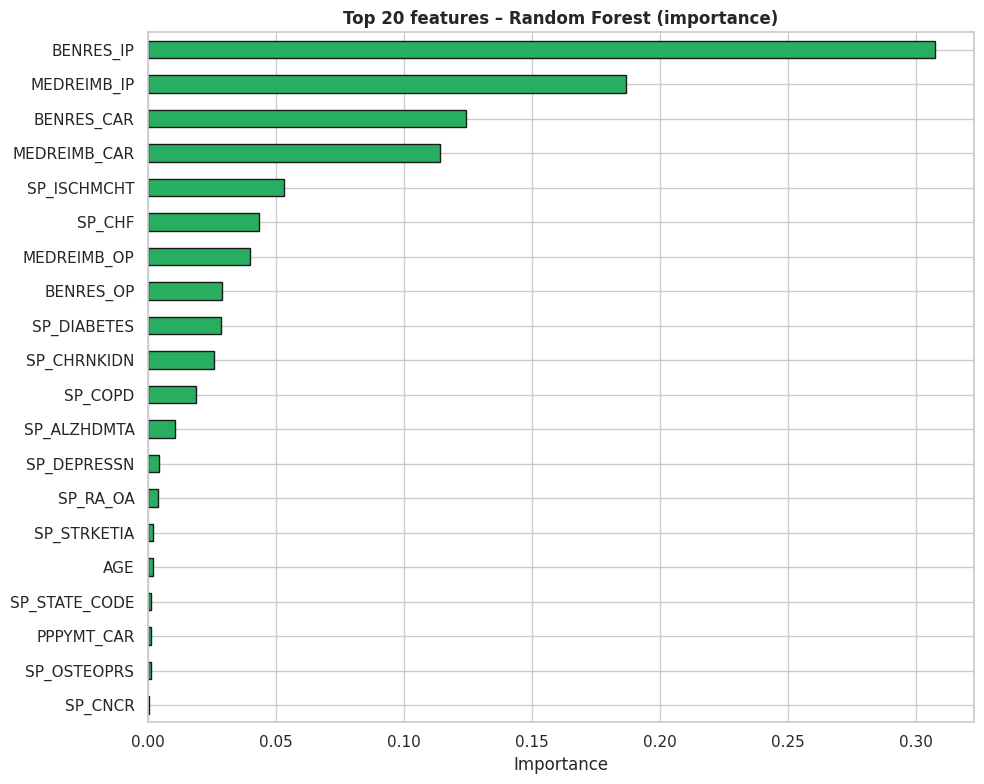

In [13]:
# ═══════════════════════════════════════════════════════════
# Cellule 13 : Importance des variables (Random Forest)
# ═══════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier

X_full = pd.get_dummies(df_patients[['AGE','SEXE','RACE'] + chronic_cols + cost_cols], drop_first=True)
y_full = df_patients['HOSPITALIZED_IN_6M']

if y_full.nunique() < 2:
    print("⚠️ Cible constante – Random Forest non applicable.")
else:
    rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1, class_weight='balanced')
    rf.fit(X_full, y_full)
    imp = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10,8))
    imp.sort_values().plot(kind='barh', color='#27ae60', edgecolor='k')
    plt.title('Top 20 features – Random Forest (importance)', fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'multivariate_rf_importance_improved.png', dpi=150)
    plt.show()

Taux d'hospitalisation par cluster :
cluster
0    0.144623
1    0.959685
2    0.550227
Name: cible, dtype: float64


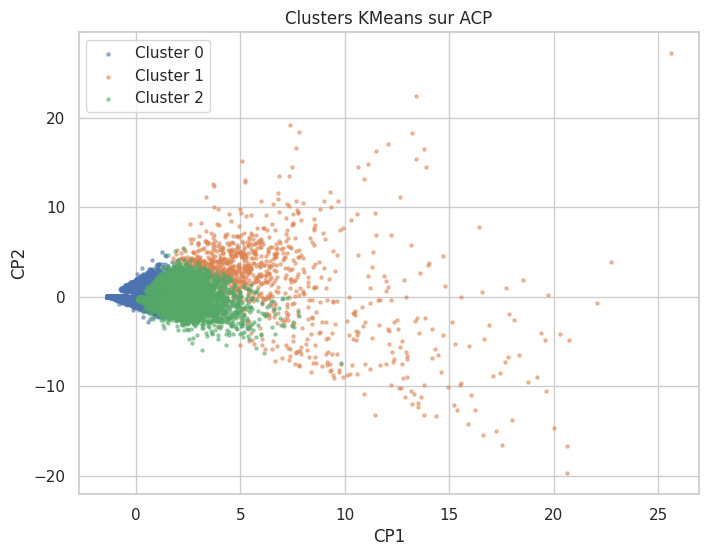

In [14]:
# ═══════════════════════════════════════════════════════════
# Cellule 14 : Clustering KMeans sur l’ACP
# ═══════════════════════════════════════════════════════════
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_clust = pd.DataFrame({'CP1':X_pca[:,0], 'CP2':X_pca[:,1], 'cluster':clusters, 'cible':y})

cluster_rate = df_clust.groupby('cluster')['cible'].mean()
print("Taux d'hospitalisation par cluster :")
print(cluster_rate)

plt.figure(figsize=(8,6))
for cl in sorted(df_clust['cluster'].unique()):
    mask = df_clust['cluster']==cl
    plt.scatter(df_clust.loc[mask,'CP1'], df_clust.loc[mask,'CP2'], 
                label=f'Cluster {cl}', alpha=0.5, s=5)
plt.xlabel('CP1')
plt.ylabel('CP2')
plt.legend()
plt.title('Clusters KMeans sur ACP')
plt.savefig(OUTPUT_DIR + 'multivariate_clusters_improved.png', dpi=150)
plt.show()

In [15]:
# ═══════════════════════════════════════════════════════════
# Cellule 15 : Synthèse
# ═══════════════════════════════════════════════════════════
print("="*60)
print("RÉSUMÉ DE L'EDA AMÉLIORÉE")
print("="*60)
print(f"Patients : {len(df_patients):,}")
unique_ages = df_patients['AGE'].unique()
if len(unique_ages) == 1:
    print(f"Âge (tous identiques) : {unique_ages[0]:.1f} ans")
else:
    print(f"Âge moyen : {df_patients['AGE'].mean():.1f} ans")
print(f"% femmes : {df_patients['SEXE'].value_counts(normalize=True).get('Femme',0)*100:.1f}%")
print(f"Taux d'hospitalisation : {df_patients['HOSPITALIZED_IN_6M'].mean()*100:.2f}%")
print(f"\nNombre de claims conservés :")
for ct in ['inpatient','outpatient','carrier','prescription']:
    print(f"  {ct}: {len(claims[ct]):,} lignes")
print("\n✅ EDA amélioré terminé !")

RÉSUMÉ DE L'EDA AMÉLIORÉE
Patients : 30,000
Âge moyen : 72.1 ans
% femmes : 55.3%
Taux d'hospitalisation : 25.57%

Nombre de claims conservés :
  inpatient: 17,325 lignes
  outpatient: 205,642 lignes
  carrier: 1,233,861 lignes
  prescription: 1,436,994 lignes

✅ EDA amélioré terminé !
